In [69]:
# STEP 1: Install dependencies
!pip install torch torchvision torchaudio
!pip install torch-scatter torch-sparse torch-geometric -f https://data.pyg.org/whl/torch-2.0.0+cpu.html


Looking in links: https://data.pyg.org/whl/torch-2.0.0+cpu.html


In [70]:
# STEP 2: Import packages
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors
import torch
from torch_geometric.data import Data


In [71]:
# STEP 3: Upload your cleaned CSV file
from google.colab import files
uploaded = files.upload()  # upload 'clean_listings_32827.csv'


Saving clean_listings_32827.csv to clean_listings_32827 (1).csv


In [72]:
# STEP 4: Load and inspect the data
df = pd.read_csv('clean_listings_32827.csv')
print(df.shape)
df.head()


(2294, 21)


,id,formattedaddress,addressline1,addressline2,city,state,zipcode,county,latitude,longitude,...,bedrooms,bathrooms,squarefootage,lotsize,yearbuilt,status,price,listeddate,daysonmarket,log_price
0,"13438-Leggett-Aly,-Orlando,-FL-32827","13438 Leggett Aly, Orlando, FL 32827",13438 Leggett Aly,NaN,Orlando,FL,32827,Orange,28.351516,-81.252638,...,5.0,4.0,3799.0,5399.0,2024.0,Active,949990,2023-07-07T00:00:00.000Z,640,13.764208
1,"14563-Orchid-Island-Dr,-Orlando,-FL-32827","14563 Orchid Island Dr, Orlando, FL 32827",14563 Orchid Island Dr,NaN,Orlando,FL,32827,Orange,28.354202,-81.240449,...,4.0,3.0,1809.0,2113.0,2021.0,Active,580000,2024-02-24T00:00:00.000Z,408,13.270785
2,"13195-Lessing-Ave,-Orlando,-FL-32827","13195 Lessing Ave, Orlando, FL 32827",13195 Lessing Ave,NaN,Orlando,FL,32827,Orange,28.375337,-81.250502,...,5.0,4.0,4327.0,17424.0,2016.0,Active,1495000,2024-04-19T00:00:00.000Z,353,14.217637
3,"7517-Laureate-Blvd,-Unit-4403,-Orlando,-FL-32827","7517 Laureate Blvd, Unit 4403, Orlando, FL 32827",7517 Laureate Blvd,Unit 4403,Orlando,FL,32827,Orange,28.368288,-81.270699,...,2.0,2.0,1549.0,1742.0,2019.0,Active,389000,2024-05-08T00:00:00.000Z,334,12.871337
4,"13661-Granger-Ave,-Orlando,-FL-32827","13661 Granger Ave, Orlando, FL 32827",13661 Granger Ave,NaN,Orlando,FL,32827,Orange,28.370972,-81.255096,...,5.0,4.0,4650.0,10454.0,2016.0,Active,1695000,2024-05-08T00:00:00.000Z,334,14.343194


In [73]:
# Assuming your dataset is a pandas DataFrame named df
# Replace with actual name if different

categorical_columns = df.select_dtypes(include=['object', 'category']).columns

print("Categorical columns and their unique values:\n")
for col in categorical_columns:
    print(f"{col}:")
    print(df[col].unique())
    print("-" * 40)


Categorical columns and their unique values:

id:
['13438-Leggett-Aly,-Orlando,-FL-32827'
 '14563-Orchid-Island-Dr,-Orlando,-FL-32827'
 '13195-Lessing-Ave,-Orlando,-FL-32827' ...
 '9573-Leland-Dr,-Orlando,-FL-32827'
 '9689-Bryanston-Dr,-Orlando,-FL-32827'
 '8453-Laureate-Blvd,-Orlando,-FL-32827']
----------------------------------------
formattedaddress:
['13438 Leggett Aly, Orlando, FL 32827'
 '14563 Orchid Island Dr, Orlando, FL 32827'
 '13195 Lessing Ave, Orlando, FL 32827' ...
 '9573 Leland Dr, Orlando, FL 32827'
 '9689 Bryanston Dr, Orlando, FL 32827'
 '8453 Laureate Blvd, Orlando, FL 32827']
----------------------------------------
addressline1:
['13438 Leggett Aly' '14563 Orchid Island Dr' '13195 Lessing Ave' ...
 '9573 Leland Dr' '9689 Bryanston Dr' '8453 Laureate Blvd']
----------------------------------------
addressline2:
[nan 'Unit 4403' 'Unit 1301' 'Unit 4205' 'Unit 1207' 'Unit 4303'
 'Unit 7203' 'Unit 4206' 'Unit 4103' 'Unit 6208' 'Unit 6301' 'Unit 7106'
 'Unit 7202' 'Uni

In [74]:
# Step 1: Define the original numerical features
features = ['bedrooms', 'bathrooms', 'squarefootage', 'lotsize', 'yearbuilt']
X_num = df[features].values.astype(np.float32)

# Step 2: One-hot encode 'propertytype'
property_dummies = pd.get_dummies(df['propertytype'], prefix='type')
X_cat = property_dummies.values.astype(np.float32)

# Step 3: Combine numerical and categorical features
X = np.hstack([X_num, X_cat])

# Step 4: Targets and coordinates
y = df['log_price'].values.astype(np.float32)
coords = df[['latitude', 'longitude']].values.astype(np.float64)


In [75]:
print("X shape:", X.shape)
print("First 5 rows of X:\n", X[:5])

print("\ny shape:", y.shape)
print("First 5 values of y:", y[:5])



X shape: (2294, 10)
First 5 rows of X:
 [[5.0000e+00 4.0000e+00 3.7990e+03 5.3990e+03 2.0240e+03 0.0000e+00
  0.0000e+00 0.0000e+00 1.0000e+00 0.0000e+00]
 [4.0000e+00 3.0000e+00 1.8090e+03 2.1130e+03 2.0210e+03 0.0000e+00
  0.0000e+00 0.0000e+00 0.0000e+00 1.0000e+00]
 [5.0000e+00 4.0000e+00 4.3270e+03 1.7424e+04 2.0160e+03 0.0000e+00
  0.0000e+00 0.0000e+00 1.0000e+00 0.0000e+00]
 [2.0000e+00 2.0000e+00 1.5490e+03 1.7420e+03 2.0190e+03 1.0000e+00
  0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00]
 [5.0000e+00 4.0000e+00 4.6500e+03 1.0454e+04 2.0160e+03 0.0000e+00
  0.0000e+00 0.0000e+00 1.0000e+00 0.0000e+00]]

y shape: (2294,)
First 5 values of y: [13.764208 13.270785 14.217637 12.871337 14.343194]


In [76]:
# STEP 6: Compute k-nearest neighbors using Haversine distance
coords_rad = np.radians(coords)
k = 8

nbrs = NearestNeighbors(n_neighbors=k + 1, algorithm='ball_tree', metric='haversine').fit(coords_rad)
distances, indices = nbrs.kneighbors(coords_rad)

edge_index_list = []
edge_attr_list = []

for i, neighbors in enumerate(indices):
    for j, neighbor in enumerate(neighbors[1:]):  # skip self
        edge_index_list.append([i, neighbor])
        edge_attr_list.append([distances[i][j + 1]])  # in radians


In [77]:
from sklearn.preprocessing import StandardScaler
# Step 1: Extract numeric and one-hot parts
X_numeric = df[['bedrooms', 'bathrooms', 'squarefootage', 'lotsize', 'yearbuilt']].values.astype(np.float32)
X_one_hot = pd.get_dummies(df['propertytype']).values.astype(np.float32)  # or however you created it
property_categories = list(pd.get_dummies(df['propertytype']).columns)

# Step 2: Scale numeric features
scaler = StandardScaler()
X_numeric_scaled = scaler.fit_transform(X_numeric)

# Step 3: Combine
X_combined = np.concatenate([X_numeric_scaled, X_one_hot], axis=1)

# Step 4: Tensor conversion
x = torch.tensor(X_combined, dtype=torch.float32)
y = torch.tensor(df['log_price'].values, dtype=torch.float32)





In [78]:
import joblib
joblib.dump(scaler, "feature_scaler.pkl")


['feature_scaler.pkl']

In [79]:
# STEP 8: Create PyTorch Geometric Data object
data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)

# Confirm the graph object
print(data)


Data(x=[2294, 10], edge_index=[2, 18352], edge_attr=[18352, 1], y=[2294])


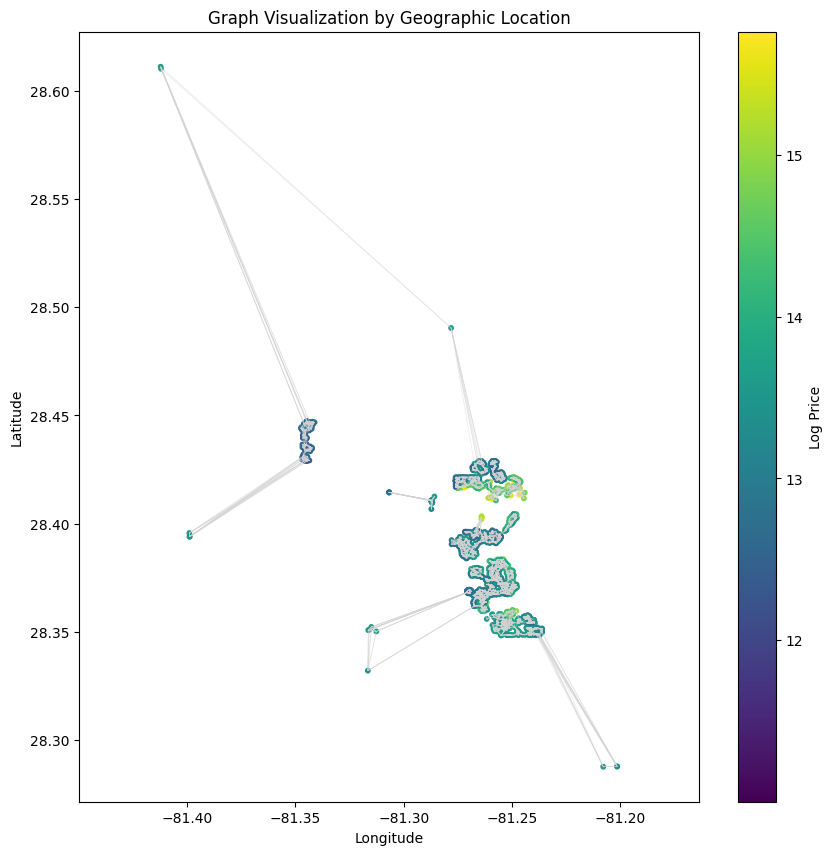

In [80]:
import matplotlib.pyplot as plt

# Get positions
pos = df[['longitude', 'latitude']].values

# Get edge list
edges = data.edge_index.numpy()

plt.figure(figsize=(10, 10))

# Plot edges
for i in range(edges.shape[1]):
    src, tgt = edges[:, i]
    x_coords = [pos[src][0], pos[tgt][0]]
    y_coords = [pos[src][1], pos[tgt][1]]
    plt.plot(x_coords, y_coords, color='lightgray', linewidth=0.5, alpha=0.5)

# Plot nodes
plt.scatter(pos[:, 0], pos[:, 1], c=df['log_price'], cmap='viridis', s=10)
plt.colorbar(label='Log Price')
plt.title("Graph Visualization by Geographic Location")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.axis('equal')
plt.show()


In [81]:
from torch_geometric.utils import train_test_split_edges

# Split into training / val / test masks
num_nodes = data.num_nodes
perm = torch.randperm(num_nodes)
train_idx = perm[:int(0.8 * num_nodes)]
test_idx  = perm[int(0.8 * num_nodes):]

data.train_mask = torch.zeros(num_nodes, dtype=torch.bool)
data.train_mask[train_idx] = True

data.test_mask = torch.zeros(num_nodes, dtype=torch.bool)
data.test_mask[test_idx] = True


In [82]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

class GCNRegressor(nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.lin = nn.Linear(hidden_channels, 1)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        return self.lin(x).squeeze()


In [83]:
model = GCNRegressor(in_channels=data.x.shape[1], hidden_channels=32)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.MSELoss()

for epoch in range(1000):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = loss_fn(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    if epoch % 10 == 0:
        test_loss = loss_fn(out[data.test_mask], data.y[data.test_mask])
        print(f'Epoch {epoch}, Train Loss: {loss.item():.4f}, Test Loss: {test_loss.item():.4f}')


Epoch 0, Train Loss: 175.0642, Test Loss: 175.2223
Epoch 10, Train Loss: 90.2780, Test Loss: 92.0217
Epoch 20, Train Loss: 35.2746, Test Loss: 28.2193
Epoch 30, Train Loss: 13.1456, Test Loss: 14.1987
Epoch 40, Train Loss: 7.7906, Test Loss: 8.7145
Epoch 50, Train Loss: 6.6758, Test Loss: 6.9633
Epoch 60, Train Loss: 6.0192, Test Loss: 6.1605
Epoch 70, Train Loss: 5.5314, Test Loss: 5.4375
Epoch 80, Train Loss: 5.1841, Test Loss: 5.1420
Epoch 90, Train Loss: 4.8969, Test Loss: 4.7710
Epoch 100, Train Loss: 4.6590, Test Loss: 4.5632
Epoch 110, Train Loss: 4.4566, Test Loss: 4.3848
Epoch 120, Train Loss: 4.2775, Test Loss: 4.1981
Epoch 130, Train Loss: 4.1119, Test Loss: 4.0589
Epoch 140, Train Loss: 3.9532, Test Loss: 3.9139
Epoch 150, Train Loss: 3.8009, Test Loss: 3.7786
Epoch 160, Train Loss: 3.6494, Test Loss: 3.6497
Epoch 170, Train Loss: 3.4968, Test Loss: 3.5246
Epoch 180, Train Loss: 3.3327, Test Loss: 3.3936
Epoch 190, Train Loss: 3.1479, Test Loss: 3.2365
Epoch 200, Train Loss

In [84]:
# ⚠️ Run this only once per session
# Restart runtime if this fails midway
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install torch-scatter torch-sparse torch-geometric -f https://data.pyg.org/whl/torch-2.0.1+cu118.html


Looking in indexes: https://download.pytorch.org/whl/cu118
Looking in links: https://data.pyg.org/whl/torch-2.0.1+cu118.html


In [85]:
import torch
import torch.nn.functional as F
from torch.nn import Linear
from torch_geometric.nn import TransformerConv

class PD_TGCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels=64, heads=2, dropout=0.1):
        super(PD_TGCN, self).__init__()
        self.conv1 = TransformerConv(in_channels, hidden_channels, heads=heads, edge_dim=1)
        self.conv2 = TransformerConv(hidden_channels * heads, hidden_channels, heads=heads, edge_dim=1)
        self.lin1 = Linear(hidden_channels * heads, hidden_channels)
        self.lin2 = Linear(hidden_channels, 1)
        self.dropout = dropout

    def forward(self, x, edge_index, edge_attr):
        x = self.conv1(x, edge_index, edge_attr)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index, edge_attr)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.lin1(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        return self.lin2(x).squeeze()


In [89]:
transformer_model = PD_TGCN(in_channels=x.shape[1])


In [90]:
transformer_optimizer = torch.optim.Adam(transformer_model.parameters(), lr=0.02, weight_decay=1e-5)


In [91]:
# Train the transformer model
import torch
import torch.nn.functional as F
from sklearn.model_selection import train_test_split

# Split your indices into train and test
indices = np.arange(len(y))
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42)

train_idx = torch.tensor(train_idx, dtype=torch.long)
test_idx = torch.tensor(test_idx, dtype=torch.long)

# Train the transformer GCN
def train_transformer(model, data, epochs=300):
    for epoch in range(epochs):
        model.train()
        transformer_optimizer.zero_grad()
        out = model(data.x, data.edge_index, data.edge_attr)
        loss = F.mse_loss(out[train_idx], data.y[train_idx])
        loss.backward()
        transformer_optimizer.step()

        if epoch % 10 == 0 or epoch == epochs - 1:
            model.eval()
            with torch.no_grad():
                test_out = model(data.x, data.edge_index, data.edge_attr)
                test_loss = F.mse_loss(test_out[test_idx], data.y[test_idx])
                print(f"Epoch {epoch}, Train Loss: {loss.item():.4f}, Test Loss: {test_loss.item():.4f}")

# Normalize edge_attr (standardize)
data.edge_attr = (data.edge_attr - data.edge_attr.mean()) / data.edge_attr.std()

train_transformer(transformer_model, data, epochs=50)


Epoch 0, Train Loss: 185.3330, Test Loss: 103.7378
Epoch 10, Train Loss: 8.0175, Test Loss: 5.9351
Epoch 20, Train Loss: 4.1067, Test Loss: 3.7225
Epoch 30, Train Loss: 3.8548, Test Loss: 1.6609
Epoch 40, Train Loss: 3.0353, Test Loss: 1.4817
Epoch 49, Train Loss: 2.8192, Test Loss: 0.9431


In [97]:
def one_hot_property_type(value, categories):
    """Create a one-hot encoded vector for a single property type string."""
    return np.array([1.0 if value == cat else 0.0 for cat in categories], dtype=np.float32)

def predict_price(new_house, df_existing, trained_model, scaler, property_categories, k=8):
    feature_cols = ['bedrooms', 'bathrooms', 'squarefootage', 'lotsize', 'yearbuilt']
    raw_numeric = np.array([[new_house[feat] for feat in feature_cols]], dtype=np.float32)
    scaled_numeric = scaler.transform(raw_numeric)

    # ✅ Manual one-hot encoding using categories from training
    onehot_property = one_hot_property_type(new_house['propertytype'], property_categories)

    # Combine scaled numeric + one-hot categorical features
    full_features = np.hstack([scaled_numeric, onehot_property.reshape(1, -1)])

    # Coordinates for neighbor lookup
    coords_existing = df_existing[['latitude', 'longitude']].values
    coords_new = np.array([[new_house['latitude'], new_house['longitude']]])
    coords_rad_existing = np.radians(coords_existing)
    coords_rad_new = np.radians(coords_new)

    nbrs = NearestNeighbors(n_neighbors=k, metric='haversine').fit(coords_rad_existing)
    distances_rad, indices = nbrs.kneighbors(coords_rad_new)
    distances_km = distances_rad * 6371

    # Build new input graph
    neighbor_feats = data.x[indices[0]].cpu().numpy()
    all_features = np.vstack([full_features, neighbor_feats])
    x = torch.tensor(all_features, dtype=torch.float32)

    edge_index = torch.tensor([[0]*k, list(range(1, k+1))], dtype=torch.long)
    edge_attr = torch.tensor(distances_km[0][:, None], dtype=torch.float32)
    edge_attr = (edge_attr - edge_attr.mean()) / edge_attr.std()
    edge_index = torch.cat([edge_index, edge_index.flip(0)], dim=1)
    edge_attr = torch.cat([edge_attr, edge_attr], dim=0)

    # Inference
    trained_model.eval()
    with torch.no_grad():
        if isinstance(trained_model, PD_TGCN):
            out = trained_model(x, edge_index, edge_attr)
            print("GCN Model ")
        else:
            out = trained_model(x, edge_index)
            print("Transformer GCN Model ")

        log_price = np.clip(out[0].item(), 10, 15)
        price = round(np.exp(log_price), 2)

    print("Predicted price: $", price)
    return price



In [99]:
sample_inputs = [
    {
        'latitude': 28.540, 'longitude': -81.379,  # Downtown Orlando
        'bedrooms': 3, 'bathrooms': 2, 'squarefootage': 1450,
        'lotsize': 0.15, 'yearbuilt': 1985, 'propertytype': 'single_family'
    },
    {
        'latitude': 28.602, 'longitude': -81.200,  # Oviedo
        'bedrooms': 2, 'bathrooms': 1.5, 'squarefootage': 1100,
        'lotsize': 0.08, 'yearbuilt': 2005, 'propertytype': 'townhouse'
    },
    {
        'latitude': 28.385, 'longitude': -81.562,  # Celebration
        'bedrooms': 1, 'bathrooms': 1, 'squarefootage': 900,
        'lotsize': 0.05, 'yearbuilt': 2010, 'propertytype': 'condo'
    },
    {
        'latitude': 28.451, 'longitude': -81.469,  # Dr. Phillips
        'bedrooms': 5, 'bathrooms': 4, 'squarefootage': 4000,
        'lotsize': 0.4, 'yearbuilt': 2018, 'propertytype': 'single_family'
    },
    {
        'latitude': 28.565, 'longitude': -81.242,  # Winter Park
        'bedrooms': 3, 'bathrooms': 2.5, 'squarefootage': 1800,
        'lotsize': 0.12, 'yearbuilt': 1995, 'propertytype': 'townhouse'
    },
    {
        'latitude': 28.693, 'longitude': -81.556,  # Apopka
        'bedrooms': 0, 'bathrooms': 0, 'squarefootage': 0,
        'lotsize': 1.0, 'yearbuilt': 2023, 'propertytype': 'land'
    },
    {
        'latitude': 28.365, 'longitude': -81.265,  # Kissimmee
        'bedrooms': 4, 'bathrooms': 3, 'squarefootage': 2600,
        'lotsize': 0.13, 'yearbuilt': 2015, 'propertytype': 'single_family'
    },
    {
        'latitude': 28.489, 'longitude': -81.191,  # East Orlando
        'bedrooms': 2, 'bathrooms': 1, 'squarefootage': 950,
        'lotsize': 0.1, 'yearbuilt': 1980, 'propertytype': 'condo'
    },
    {
        'latitude': 28.524, 'longitude': -81.465,  # MetroWest
        'bedrooms': 3, 'bathrooms': 2, 'squarefootage': 1350,
        'lotsize': 0.12, 'yearbuilt': 2003, 'propertytype': 'multi-family'
    },
    {
        'latitude': 28.677, 'longitude': -81.209,  # Sanford
        'bedrooms': 5, 'bathrooms': 3.5, 'squarefootage': 3100,
        'lotsize': 0.25, 'yearbuilt': 2020, 'propertytype': 'single_family'
    }
]
for i, house in enumerate(sample_inputs, 1):
    print(f"\n--- Prediction for Sample {i} ---")
    predict_price(house, df_existing=df, trained_model=transformer_model, scaler=scaler, property_categories=property_categories)
    predict_price(house, df_existing=df, trained_model=model, scaler=scaler, property_categories=property_categories)




--- Prediction for Sample 1 ---
GCN Model 
Predicted price: $ 3269017.37
Transformer GCN Model 
Predicted price: $ 746651.32

--- Prediction for Sample 2 ---
GCN Model 
Predicted price: $ 3269017.37
Transformer GCN Model 
Predicted price: $ 1465036.27

--- Prediction for Sample 3 ---
GCN Model 
Predicted price: $ 3269017.37
Transformer GCN Model 
Predicted price: $ 585971.18

--- Prediction for Sample 4 ---
GCN Model 
Predicted price: $ 3269017.37
Transformer GCN Model 
Predicted price: $ 539198.87

--- Prediction for Sample 5 ---
GCN Model 
Predicted price: $ 3269017.37
Transformer GCN Model 
Predicted price: $ 1273181.86

--- Prediction for Sample 6 ---
GCN Model 
Predicted price: $ 3269017.37
Transformer GCN Model 
Predicted price: $ 131368.65

--- Prediction for Sample 7 ---
GCN Model 
Predicted price: $ 2425813.09
Transformer GCN Model 
Predicted price: $ 1898910.62

--- Prediction for Sample 8 ---
GCN Model 
Predicted price: $ 3269017.37
Transformer GCN Model 
Predicted price: $

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def evaluate_model(model, data, test_idx, label='GCN'):
    model.eval()
    with torch.no_grad():
        if isinstance(model, PD_TGCN):
            pred_log = model(data.x, data.edge_index, data.edge_attr)[test_idx]
        else:
            pred_log = model(data.x, data.edge_index)[test_idx]

        true_log = data.y[test_idx]

        # Convert back from log to dollar values
        y_true = np.exp(true_log.cpu().numpy())
        y_pred = np.exp(pred_log.cpu().numpy())

        # Plot
        plt.figure(figsize=(6, 6))
        plt.scatter(y_true, y_pred, alpha=0.6)
        plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
        plt.xlabel("True Price ($)")
        plt.ylabel("Predicted Price ($)")
        plt.title(f"{label} Price Prediction Calibration")
        plt.grid(True)
        plt.show()

        # Return predictions if you want to analyze further
        return y_true, y_pred


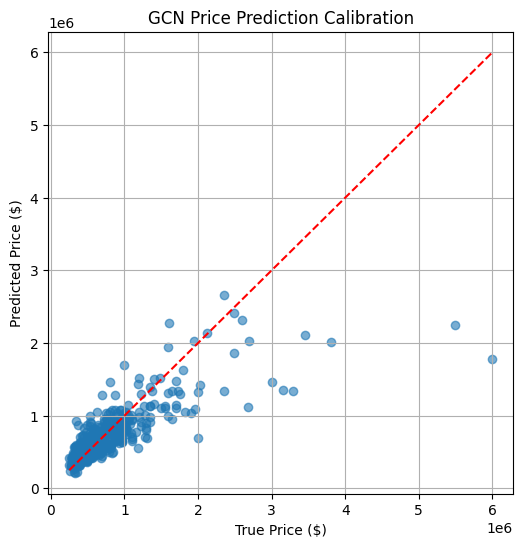

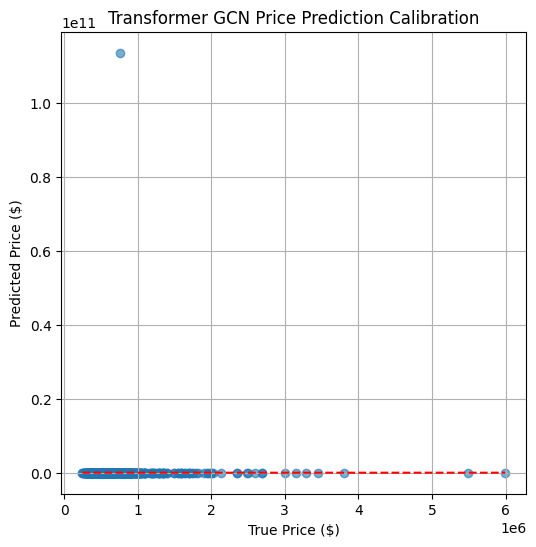

In [ ]:
y_true_gcn, y_pred_gcn = evaluate_model(model, data, test_idx, label='GCN')
y_true_tgnn, y_pred_tgnn = evaluate_model(transformer_model, data, test_idx, label='Transformer GCN')


In [ ]:
sample_input1 = {
    'latitude': 28.366,
    'longitude': -81.268,
    'bedrooms': 4,
    'bathrooms': 3,
    'squarefootage': 2600,
    'lotsize': 0.13,
    'yearbuilt': 2015
}
sample_input2 = {
    'latitude': 28.355,
    'longitude': -81.270,
    'bedrooms': 5,
    'bathrooms': 4,
    'squarefootage': 3400,
    'lotsize': 0.25,
    'yearbuilt': 2020
}
sample_input3 = {
    'latitude': 28.371,
    'longitude': -81.260,
    'bedrooms': 2,
    'bathrooms': 2,
    'squarefootage': 1200,
    'lotsize': 0.05,
    'yearbuilt': 2012
}
sample_input4 = {
    'latitude': 28.362,
    'longitude': -81.250,
    'bedrooms': 3,
    'bathrooms': 2,
    'squarefootage': 1800,
    'lotsize': 0.2,
    'yearbuilt': 1970
}
sample_input5 = {
    'latitude': 28.345,
    'longitude': -81.245,
    'bedrooms': 2,
    'bathrooms': 1,
    'squarefootage': 950,
    'lotsize': 0.1,
    'yearbuilt': 1985
}
for i, sample in enumerate([sample_input1, sample_input2, sample_input3, sample_input4, sample_input5], 1):
    print(f"\nPrediction for Sample {i} (GCN):")
    predict_price(sample, df_existing=df, trained_model=model, scaler=scaler)

    print(f"Prediction for Sample {i} (Transformer GCN):")
    predict_price(sample, df_existing=df, trained_model=transformer_model, scaler=scaler)



Prediction for Sample 1 (GCN):
Predicted price: $ 3269017.37
Prediction for Sample 1 (Transformer GCN):
Predicted price: $ 1038928.69

Prediction for Sample 2 (GCN):
Predicted price: $ 3269017.37
Prediction for Sample 2 (Transformer GCN):
Predicted price: $ 3269017.37

Prediction for Sample 3 (GCN):
Predicted price: $ 3269017.37
Prediction for Sample 3 (Transformer GCN):
Predicted price: $ 681733.45

Prediction for Sample 4 (GCN):
Predicted price: $ 3269017.37
Prediction for Sample 4 (Transformer GCN):
Predicted price: $ 3269017.37

Prediction for Sample 5 (GCN):
Predicted price: $ 3269017.37
Prediction for Sample 5 (Transformer GCN):
Predicted price: $ 3269017.37
